In [1]:
import pandas as pd

df_predictors = pd.read_csv(r"E:\SI\Predictors\Predictor for SRC adjustment factors across CONUS.txt")

In [2]:
# convert COMID to int
df_predictors['COMID'] = df_predictors['COMID'].astype(int)
df_predictors

,Unnamed: 0,COMID,TotDASqKM,CAT_SILTAVE,QE_cms,D50_mm_,HydraulicRadius (m),Volume (m3),WetArea (m2),HYDRLCONDCAT,WTDEPCAT,PERMCAT,StreamOrde
0,0,721640,3197.9700,56.40,57.948436,0.380283,15.857102,8.987655e+06,6678.264254,0.2280,106.017528,8.547650,5.0
1,1,717072,3199.7997,58.18,57.972096,0.566348,22.510113,8.290905e+06,9628.070417,0.2280,91.252273,5.220708,5.0
2,2,717076,3169.0890,54.68,48.713896,0.519356,16.320629,8.725284e+06,7572.361628,0.2221,120.284476,11.762311,5.0
3,3,717082,3101.7240,58.57,47.762792,0.452027,16.275332,9.231961e+06,6953.369666,0.0057,88.005448,4.489126,5.0
4,4,718990,3092.9895,59.09,47.644016,0.566348,17.402589,4.761972e+06,5712.860920,0.0164,83.660000,3.510000,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2161049,2190022,22599701,13.7547,42.28,0.000392,0.393875,25.298397,1.152848e+07,9225.329640,118.9469,154.380000,18.110000,1.0
2161050,2190023,22599699,3.9033,42.28,0.000084,0.451528,22.653490,1.951305e+07,15406.845152,127.8264,154.380000,18.110000,1.0
2161051,2190024,22599697,10.7127,42.28,0.000308,0.393875,25.298400,3.787170e+06,36118.856685,127.8264,154.380000,18.110000,1.0
2161052,2190026,22594551,15.5160,30.78,0.001176,0.293480,16.555852,1.002763e+07,7387.374976,3.9932,182.880000,14.784311,1.0


In [3]:
# Verify if the COMID is present in the dataframe
comid_to_check = 8755683
is_present = df_predictors['COMID'].isin([comid_to_check]).any()
is_present

True

In [4]:
df_predictors[df_predictors['COMID'].isin([comid_to_check])]

,Unnamed: 0,COMID,TotDASqKM,CAT_SILTAVE,QE_cms,D50_mm_,HydraulicRadius (m),Volume (m3),WetArea (m2),HYDRLCONDCAT,WTDEPCAT,PERMCAT,StreamOrde
161415,163586,8755683,1.3176,14.09,0.017668,0.382115,21.036229,1.585062e+07,15449.24397,3.9298,138.22,17.63,1.0


### Additional predictors — EVI (vegetation) + STATSGO (soil), CONUS-wide

Seasonal EVI is a proxy for riparian/floodplain vegetation density, which physically
drives overbank Manning's n. STATSGO accumulated soil attributes (grain-size fractions,
organic matter, permeability, bulk density, rock depth) relate to channel-bed roughness.
Both are read directly from the zip files in `E:\SI\Predictors\Additional` (pandas can
read a single-file zip without extracting) and merged onto `df_predictors` by COMID.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

EXTRA_DIR = Path(r"E:\SI\Predictors\Additional")

evi_files = {
    "JAS_2012": "EVI_JAS_2012_CONUS.zip",
    "JFM_2012": "EVI_JFM_2012_CONUS.zip",
    "OND_2011": "EVI_OND_2011_CONUS.zip",
}

df_extra = None
for tag, fname in evi_files.items():
    d = pd.read_csv(EXTRA_DIR / fname, usecols=lambda c: c.startswith("COMID") or c.startswith("CAT_EVI"))
    d = d.rename(columns={d.columns[1]: f"EVI_{tag}"})
    df_extra = d if df_extra is None else df_extra.merge(d, on="COMID", how="outer")

df_statsgo = pd.read_csv(EXTRA_DIR / "STATSGO_LAYER_ACC_CONUS.zip")
df_statsgo = df_statsgo.drop(columns=["ACC_NODATA"], errors="ignore")
df_extra = df_extra.merge(df_statsgo, on="COMID", how="outer")

# StreamCat: hydraulic conductivity + 1981-2010 precip normals, watershed (ws)
# vs catchment-local (cat) variants, keyed by lowercase "comid".
# hydrlcondcat is dropped -- verified an EXACT duplicate of the HYDRLCONDCAT
# column already in the base predictor file (corr=1.0, max diff=0.0 across
# all 2.16M COMIDs); keeping both would silently double-weight one variable.
# hydrlcondws (corr=0.79 vs hydrlcondcat) and both precip8110 variants
# (corr=0.98 to each other, but neither exists anywhere else) are new signal.
df_hydrlcond = pd.read_csv(EXTRA_DIR / "streamcat_hydrlcond_output.csv")[["comid", "hydrlcondws"]]
df_precip    = pd.read_csv(EXTRA_DIR / "streamcat_precip8110_output.csv")

df_streamcat = df_hydrlcond.merge(df_precip, on="comid", how="outer")
df_streamcat = df_streamcat.rename(columns={
    "comid": "COMID", "hydrlcondws": "HYDRLCOND_WS",
    "precip8110ws": "PRECIP8110_WS", "precip8110cat": "PRECIP8110_CAT",
})
df_extra = df_extra.merge(df_streamcat, on="COMID", how="outer")

EXTRA_FEATURE_COLS = [c for c in df_extra.columns if c != "COMID"]

# EVI/STATSGO/StreamCat all use -9999 as their NODATA sentinel (confirmed in
# the raw files for catchments with no coverage, e.g. coastline/ocean
# placeholders -- 0 hits in the two new StreamCat files, but checking anyway).
# Left as-is, a stray -9999 would be treated as a real extreme feature value
# by every model here (and would badly distort Ridge/Lasso's standardization),
# so mask it to NaN before it can reach training -- currently a no-op for our
# 99 gauges (checked directly), but a real guard once more HUCs/gauges are added.
sentinel_hits = (df_extra[EXTRA_FEATURE_COLS] == -9999).sum()
sentinel_hits = sentinel_hits[sentinel_hits > 0]
if len(sentinel_hits):
    print(f"Masking -9999 NODATA sentinel in: {sentinel_hits.to_dict()}")
df_extra[EXTRA_FEATURE_COLS] = df_extra[EXTRA_FEATURE_COLS].replace(-9999, np.nan)

print(f"Additional predictors loaded: {EXTRA_FEATURE_COLS}")
print(f"df_extra: {len(df_extra)} COMIDs")

# fold into the main predictor table used downstream
df_predictors = df_predictors.merge(df_extra, on="COMID", how="left")
print(f"df_predictors now has {df_predictors.shape[1]} columns, {len(df_predictors)} rows")

# defensive check on the ORIGINAL 11 predictor columns too -- different source
# file, unknown NODATA convention, but flag anything that looks like a sentinel
# rather than silently trusting it
orig_cols = ["TotDASqKM", "CAT_SILTAVE", "QE_cms", "D50_mm_", "HydraulicRadius (m)",
             "Volume (m3)", "WetArea (m2)", "HYDRLCONDCAT", "WTDEPCAT", "PERMCAT", "StreamOrde"]
suspect = {c: int((df_predictors[c] <= -100).sum()) for c in orig_cols
           if (df_predictors[c] <= -100).any()}
if suspect:
    print(f"\u26a0  Suspiciously negative values (possible sentinel) in original predictors: {suspect}")
else:
    print("No suspicious sentinel-like values found in the original 11 predictor columns.")

Masking -9999 NODATA sentinel in: {'EVI_JAS_2012': 487, 'EVI_JFM_2012': 488, 'EVI_OND_2011': 490, 'ACC_KFACT': 8520, 'ACC_KFACT_UP': 8520, 'ACC_NO10AVE': 8520, 'ACC_NO200AVE': 8520, 'ACC_NO4AVE': 8520, 'ACC_OM': 8520, 'ACC_PERMAVE': 8520, 'ACC_RFACT': 8520, 'ACC_ROCKDEP': 8520, 'ACC_BDAVE': 8520, 'ACC_AWCAVE': 8520, 'ACC_WTDEP': 8520}
Additional predictors loaded: ['EVI_JAS_2012', 'EVI_JFM_2012', 'EVI_OND_2011', 'ACC_KFACT', 'ACC_KFACT_UP', 'ACC_NO10AVE', 'ACC_NO200AVE', 'ACC_NO4AVE', 'ACC_OM', 'ACC_PERMAVE', 'ACC_RFACT', 'ACC_ROCKDEP', 'ACC_BDAVE', 'ACC_AWCAVE', 'ACC_WTDEP', 'HYDRLCOND_WS', 'PRECIP8110_WS', 'PRECIP8110_CAT']
df_extra: 2699864 COMIDs
df_predictors now has 31 columns, 2161054 rows
No suspicious sentinel-like values found in the original 11 predictor columns.


# Stage-Dependent Manning's n — Calibration & XGBoost Regionalization

**Goal:** Extract zone-specific Manning's n values written by s05 into calibrated SRC files, then train an XGBoost model to regionalize those values across ungauged CONUS reaches using watershed/channel predictors.

**Workflow:**

| Step | Cell | Disk needed? |
|------|------|-------------|
| Build `n_zones_summary.csv` from s05 outputs | Step 0 (`RECOMPUTE_SUMMARY = True`) | Yes — once |
| Load existing summary | Step 0 (`RECOMPUTE_SUMMARY = False`) | No |
| Merge with CONUS predictors + train XGBoost | Steps 1–2 | No |

### Step 0 — Build `n_zones_summary.csv` from s05 outputs

Reads `zonal_n_applied` written by s05 directly from the calibrated SRC files.  
Set `RECOMPUTE_SUMMARY = True` the first time (disk connected), then switch to `False`.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

# ── Two data locations ───────────────────────────────────────────────────────────────────
ML_DIR   = Path(r"E:\SI")  # HUC list, summary CSV
DISK_DIR = Path(r"E:\SI\out")                                        # ncalib_diagnostics.csv per HUC (hard disk, needed only once)
OUT_DIR  = Path(r"E:\SI\out\ML")                # summary CSV (saved to ML_DIR)

HUC_LIST_PATH    = ML_DIR / "HUC.txt"
SUMMARY_OUT      = ML_DIR / "n_zones_summary.csv"
RECURRENCE_YEARS = [2, 5, 10, 25, 50]

# Zone-n clip bounds from scripts/s05_ncalib_core.py (N_MIN/N_MAX) — any zone
# value sitting exactly on a bound is the optimizer pinned against the cap,
# not a real calibrated roughness, so it must not be used as an ML label.
N_MIN_BOUND = 0.010
N_MAX_BOUND = 0.300

# ── Flag ───────────────────────────────────────────────────────────────────────────
RECOMPUTE_SUMMARY = True   # True  → read ncalib_diagnostics.csv from hard disk, save CSV to ML_DIR
                            # False → load existing n_zones_summary.csv from ML_DIR (no disk needed)
# ─────────────────────────────────────────────────────────────────────────────

if RECOMPUTE_SUMMARY:
    hucs = pd.read_csv(HUC_LIST_PATH, dtype=str)["HUC"].tolist()
    print(f"HUCs: {hucs}")

    n_cols     = [f"n_{yr}yr" for yr in RECURRENCE_YEARS]
    n_eff_cols = [f"n_eff_{yr}yr" for yr in RECURRENCE_YEARS]

    all_rows = []
    total_pinned = 0
    for huc8 in hucs:
        diag_path = DISK_DIR / f"HUC{huc8}" / "ncalib_diagnostics.csv"
        if not diag_path.exists():
            print(f"HUC {huc8}: ncalib_diagnostics.csv not found -- skipping")
            continue

        diag = pd.read_csv(
            diag_path,
            dtype={"huc8": str, "branch": str, "location_id": str},
        )
        diag = diag[diag["status"] == "calibrated"].copy()
        if diag.empty:
            print(f"HUC {huc8}: no calibrated rows -- skipping")
            continue

        diag["feature_id"] = diag["feature_id"].astype(int)
        diag = diag.rename(columns={
            "huc8": "HUC8", "branch": "levpa_id", "hydroid": "HydroID",
        })

        # target = raw calibrated n (pre clip/monotonic-fix); drop the
        # effective-n columns so n_{yr}yr keeps its original values
        diag = diag.drop(columns=n_eff_cols, errors="ignore")

        # mask pinned zone-values: a value sitting exactly on N_MIN/N_MAX
        # means the optimizer hit its bound, not a physically meaningful n
        pinned_mask = diag[n_cols].isin([N_MIN_BOUND, N_MAX_BOUND])
        total_pinned += int(pinned_mask.to_numpy().sum())
        diag[n_cols] = diag[n_cols].mask(pinned_mask)

        keep_cols = ["HUC8", "location_id", "feature_id", "HydroID", "levpa_id"] + n_cols + ["h0_elev_m"]
        all_rows.append(diag[keep_cols])
        print(f"HUC {huc8}: {len(diag)} calibrated gauge rows")

    df_n_zones = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    df_n_zones.to_csv(SUMMARY_OUT, index=False)
    print(f"\nMasked {total_pinned} pinned zone-values (exactly at N_MIN={N_MIN_BOUND} or N_MAX={N_MAX_BOUND}) to NaN")
    print(f"Saved {len(df_n_zones)} rows to {SUMMARY_OUT}")
    print("Disconnect the hard disk and set RECOMPUTE_SUMMARY = False for future runs.")

else:
    if not SUMMARY_OUT.exists():
        raise FileNotFoundError(
            f"{SUMMARY_OUT} not found. Set RECOMPUTE_SUMMARY = True and re-run with hard disk connected."
        )
    df_n_zones = pd.read_csv(SUMMARY_OUT, dtype={"location_id": str, "HUC8": str})
    print(f"Loaded {len(df_n_zones)} rows from {SUMMARY_OUT}")

display(df_n_zones)

HUCs: ['03020101', '03020102', '03020103', '03020104', '03020201', '03020202', '03020203', '03020204', '03030001', '03030002', '03030003', '03030004', '03030005', '03030006', '03030007', '03040101', '03040102', '03040103', '03040104', '03040105', '03040201', '03040202', '03040203', '03040204', '03040206', '12010005', '12020003', '12020006', '12020007', '12040102', '12100201']
HUC 03020101: 5 calibrated gauge rows
HUC 03020102: 2 calibrated gauge rows
HUC 03020103: 2 calibrated gauge rows
HUC 03020104: ncalib_diagnostics.csv not found -- skipping
HUC 03020201: 17 calibrated gauge rows
HUC 03020202: 3 calibrated gauge rows
HUC 03020203: 3 calibrated gauge rows
HUC 03020204: ncalib_diagnostics.csv not found -- skipping
HUC 03030001: ncalib_diagnostics.csv not found -- skipping
HUC 03030002: 13 calibrated gauge rows
HUC 03030003: 5 calibrated gauge rows
HUC 03030004: 4 calibrated gauge rows
HUC 03030005: 2 calibrated gauge rows
HUC 03030006: 1 calibrated gauge rows
HUC 03030007: 1 calibrat

,HUC8,location_id,feature_id,HydroID,levpa_id,n_2yr,n_5yr,n_10yr,n_25yr,n_50yr,h0_elev_m
0,03020101,02082585,8762349,11580120,3351000001,0.0431,0.0568,0.0859,0.0806,0.0790,16.716567
1,03020101,02081500,8760623,11580034,3351000001,0.0397,0.0442,0.0570,0.0702,NaN,87.558177
2,03020101,02081747,8759765,11580063,3351000001,NaN,NaN,NaN,NaN,0.2924,54.337554
3,03020101,02081942,8764333,11580095,3351000001,0.0648,0.1745,0.1539,NaN,NaN,39.630955
4,03020101,0208250410,8762653,11580110,3351000001,0.0492,0.1276,0.1940,NaN,NaN,28.198384
...,...,...,...,...,...,...,...,...,...,...,...
123,12100201,08166200,3585724,25130054,1619000001,0.0347,0.0456,0.0611,0.0723,0.0677,487.826177
124,12100201,08165300,3585678,25130035,1619000001,0.0795,0.0506,0.0417,0.0408,0.0413,548.985728
125,12100201,08167500,3589120,25130151,1619000001,0.0344,0.0475,0.0564,0.0425,NaN,289.201192
126,12100201,08167200,3589062,25130115,1619000001,0.0238,NaN,NaN,NaN,NaN,350.567036


### Step 0b — Zone-specific geometry from each gauge's own hydroTable

Verified that `HydraulicRadius (m)` / `WetArea (m2)` / `Volume (m3)` in the CONUS
predictor file do **not** match this pipeline's own hydroTable geometry for the
same reach at any stage (checked 4 gauges directly — off by 30-95%, not even
proportional). That file is an independently-computed OWP CONUS product, not
this run's HAND geometry, so those three columns are replaced here with values
read directly from each gauge's own hydroTable, interpolated at the actual NWM
recurrence discharge for each zone — geometry now varies by zone instead of
being one static snapshot reused for all 5 targets.

**Caveat:** this corrected geometry only exists where we've already run HAND
(i.e. for the calibrated gauges themselves) — there is no hydroTable for the
~2.16M ungauged CONUS reaches in the predictor file, so it can only be used
for the training/CV comparison below, not for the CONUS-wide prediction step
(which still needs the external predictor file's geometry, mismatch and all,
because it's the only geometry source that exists at that scale).

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

REPO_DATA_DIR = Path(r"c:\Users\Ali\OneDrive - CUNY\Desktop\SI\fimbox_SI26\data")
GEOM_OUT = ML_DIR / "n_zones_geometry.csv"
GEOM_BASE_NAMES = ["HydraulicRadius", "WetArea", "Volume"]
GEOM_COLS_IN    = ["HydraulicRadius (m)", "WetArea (m2)", "Volume (m3)"]

if RECOMPUTE_SUMMARY:
    recur = pd.read_parquet(REPO_DATA_DIR / "nwm3_17C_recurrence_flows_cfs.parquet")
    for yr in RECURRENCE_YEARS:
        recur[f"Q_{yr}yr_cms"] = recur[f"{yr}_0_year_recurrence_flow_17C"].astype(float) * 0.028317
    recur["feature_id"] = recur["feature_id"].astype("Int64")

    ht_cache: dict[tuple, pd.DataFrame] = {}

    def load_hydrotable(huc8: str, branch: str):
        key = (huc8, branch)
        if key not in ht_cache:
            path = (DISK_DIR / f"HUC{huc8}" / "watershed-data" / "branches"
                    / branch / f"hydroTable_{branch}.csv")
            ht_cache[key] = pd.read_csv(path, dtype={"HydroID": int}) if path.exists() else None
        return ht_cache[key]

    geom_rows = []
    for _, row in df_n_zones.iterrows():
        feat_id = int(row["feature_id"])
        out = {"HUC8": row["HUC8"], "location_id": row["location_id"], "HydroID": row["HydroID"]}
        ht = load_hydrotable(row["HUC8"], row["levpa_id"])
        if ht is not None:
            hrow = ht[ht["HydroID"] == row["HydroID"]].sort_values("stage")
            feat_recur = recur[recur["feature_id"] == feat_id]
            if not hrow.empty and not feat_recur.empty:
                q_arr = hrow["discharge_cms"].values
                for yr in RECURRENCE_YEARS:
                    Q_r = float(feat_recur[f"Q_{yr}yr_cms"].iloc[0])
                    if Q_r <= 0 or Q_r < q_arr.min() or Q_r > q_arr.max():
                        continue
                    for name, col_in in zip(GEOM_BASE_NAMES, GEOM_COLS_IN):
                        out[f"{name}_{yr}yr"] = float(np.interp(Q_r, q_arr, hrow[col_in].values))
        geom_rows.append(out)

    df_geom = pd.DataFrame(geom_rows)
    df_geom.to_csv(GEOM_OUT, index=False)
    have = sum(f"{GEOM_BASE_NAMES[0]}_2yr" in r for r in geom_rows)
    print(f"Computed zone-specific geometry for {have}/{len(df_geom)} gauges -> {GEOM_OUT}")
else:
    if not GEOM_OUT.exists():
        raise FileNotFoundError(
            f"{GEOM_OUT} not found. Set RECOMPUTE_SUMMARY = True and re-run with hard disk connected."
        )
    df_geom = pd.read_csv(GEOM_OUT, dtype={"location_id": str, "HUC8": str})
    print(f"Loaded zone-specific geometry for {len(df_geom)} gauges from {GEOM_OUT}")

display(df_geom)

Computed zone-specific geometry for 101/128 gauges -> E:\SI\n_zones_geometry.csv


,HUC8,location_id,HydroID,HydraulicRadius_2yr,WetArea_2yr,Volume_2yr,HydraulicRadius_5yr,WetArea_5yr,Volume_5yr,HydraulicRadius_10yr,WetArea_10yr,Volume_10yr,HydraulicRadius_25yr,WetArea_25yr,Volume_25yr,HydraulicRadius_50yr,WetArea_50yr,Volume_50yr
0,03020101,02082585,11580120,1.167072,50.990522,8.115852e+04,1.418776,348.537192,5.547455e+05,1.741471,552.469070,8.793315e+05,2.044470,774.429525,1.232613e+06,2.190938,930.891667,1.481644e+06
1,03020101,02081500,11580034,0.404090,16.289114,2.458493e+04,1.511877,94.594455,1.427701e+05,2.101477,160.589392,2.423753e+05,2.802650,255.163010,3.851139e+05,3.265005,319.424570,4.821029e+05
2,03020101,02081747,11580063,2.014682,1801.646463,2.742128e+06,2.590216,2876.286156,4.377742e+06,2.840121,3489.875885,5.311633e+06,3.043357,4151.062176,6.317967e+06,3.170108,4526.546801,6.889459e+06
3,03020101,02081942,11580095,1.169037,333.595910,5.047384e+05,2.328504,938.578949,1.420092e+06,2.812980,1239.563996,1.875489e+06,3.231494,1571.730354,2.378065e+06,3.499964,1769.758274,2.677685e+06
4,03020101,0208250410,11580110,1.139647,144.914535,2.167333e+05,2.103318,393.934820,5.891665e+05,2.756742,590.681361,8.834195e+05,3.346425,792.470086,1.185213e+06,3.683909,915.158483,1.368706e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,12100201,08166200,25130054,0.445704,28.278761,4.298455e+04,1.058352,129.667830,1.970989e+05,1.792117,277.285330,4.214819e+05,3.226002,577.506537,8.778270e+05,4.472492,857.385272,1.303251e+06
124,12100201,08165300,25130035,0.456540,24.998286,3.749493e+04,1.227516,93.415626,1.401141e+05,1.781167,183.073734,2.745923e+05,2.607748,383.331095,5.749583e+05,3.281243,619.040645,9.284990e+05
125,12100201,08167500,25130151,1.353361,76.647073,1.161414e+05,3.667195,369.204879,5.594470e+05,4.865419,792.692532,1.201147e+06,4.102160,1808.047023,2.739689e+06,4.197774,2787.088584,4.223206e+06
126,12100201,08167200,25130115,0.804814,24.136225,3.621856e+04,3.336709,182.656353,2.740922e+05,4.589087,406.840198,6.105001e+05,5.106773,979.496306,1.469822e+06,5.196685,1706.668773,2.561009e+06


In [8]:
# ── Merge n-zones summary with CONUS predictor table + own-hydroTable geometry ──────
# df_n_zones, df_geom already in memory. df_predictors loaded earlier, extended
# with EVI + STATSGO. HydraulicRadius/WetArea/Volume come from df_geom (each
# gauge's own hydroTable, interpolated at that zone's recurrence discharge) —
# NOT from df_predictors, whose versions of those columns were verified not to
# match this pipeline's geometry for the same reach (see Step 0b markdown).
#
# The external file's geometry is kept too (renamed _EXT, not dropped) so a
# later cell can compare "own hydroTable geometry" vs "external CONUS-wide
# geometry" head to head on the exact same gauge set -- the external version
# is what a CONUS-deployable model would actually have to use.

BASE_FEATURE_COLS = [
    "TotDASqKM", "CAT_SILTAVE", "QE_cms", "D50_mm_",
    "HYDRLCONDCAT", "WTDEPCAT", "PERMCAT", "StreamOrde",
] + EXTRA_FEATURE_COLS
TARGET_COLS = ["n_2yr", "n_5yr", "n_10yr", "n_25yr", "n_50yr", "h0_elev_m"]
GEOM_BASE_NAMES = ["HydraulicRadius", "WetArea", "Volume"]
EXT_GEOM_COLS = ["HydraulicRadius (m)", "WetArea (m2)", "Volume (m3)"]
EXT_GEOM_RENAME = {c: f"{g}_EXT" for c, g in zip(EXT_GEOM_COLS, GEOM_BASE_NAMES)}

def feature_cols_for(zone: str) -> list[str]:
    # h0_elev_m isn't zone-specific; use the 2yr geometry as a near-bankfull reference
    yr = zone[len("n_"):-len("yr")] if zone.startswith("n_") and zone.endswith("yr") else "2"
    return BASE_FEATURE_COLS + [f"{g}_{yr}yr" for g in GEOM_BASE_NAMES]

EXT_FEATURE_COLS = BASE_FEATURE_COLS + [f"{g}_EXT" for g in GEOM_BASE_NAMES]

df_predictors_join = df_predictors.drop(columns=["Unnamed: 0"], errors="ignore")
df_predictors_join = df_predictors_join.rename(columns=EXT_GEOM_RENAME)

df_ml = (
    df_n_zones
    .merge(df_predictors_join, left_on="feature_id", right_on="COMID", how="inner")
    .merge(df_geom, on=["HUC8", "location_id", "HydroID"], how="left")
)

print(f"Merged dataset: {len(df_ml)} rows  |  {df_ml['location_id'].nunique()} unique gauges")
print(f"{len(BASE_FEATURE_COLS)} base features (11 orig[-3 geom] + {len(EXTRA_FEATURE_COLS)} EVI/STATSGO) "
      f"+ 3 zone-specific geometry features per target (or 3 static _EXT features for the comparison cell)")
print(f"\nAvailable targets (non-null counts):")
print(df_ml[TARGET_COLS].notna().sum().to_string())
geom_cols_all = [f"{g}_{yr}yr" for yr in RECURRENCE_YEARS for g in GEOM_BASE_NAMES]
print(f"\nZone-geometry coverage (non-null counts):")
print(df_ml[geom_cols_all].notna().sum().to_string())
df_ml[["HUC8", "location_id", "feature_id", "HydroID"] + TARGET_COLS + BASE_FEATURE_COLS + geom_cols_all + EXT_FEATURE_COLS[-3:]]

Merged dataset: 125 rows  |  125 unique gauges
26 base features (11 orig[-3 geom] + 18 EVI/STATSGO) + 3 zone-specific geometry features per target (or 3 static _EXT features for the comparison cell)

Available targets (non-null counts):
n_2yr         83
n_5yr         82
n_10yr        82
n_25yr        73
n_50yr        64
h0_elev_m    122

Zone-geometry coverage (non-null counts):
HydraulicRadius_2yr      98
WetArea_2yr              98
Volume_2yr               98
HydraulicRadius_5yr     111
WetArea_5yr             111
Volume_5yr              111
HydraulicRadius_10yr    117
WetArea_10yr            117
Volume_10yr             117
HydraulicRadius_25yr    122
WetArea_25yr            122
Volume_25yr             122
HydraulicRadius_50yr    125
WetArea_50yr            125
Volume_50yr             125


,HUC8,location_id,feature_id,HydroID,n_2yr,n_5yr,n_10yr,n_25yr,n_50yr,h0_elev_m,...,Volume_10yr,HydraulicRadius_25yr,WetArea_25yr,Volume_25yr,HydraulicRadius_50yr,WetArea_50yr,Volume_50yr,HydraulicRadius_EXT,WetArea_EXT,Volume_EXT
0,03020101,02082585,8762349,11580120,0.0431,0.0568,0.0859,0.0806,0.0790,16.716567,...,8.793315e+05,2.044470,774.429525,1.232613e+06,2.190938,930.891667,1.481644e+06,15.963237,17707.124134,1.950516e+07
1,03020101,02081500,8760623,11580034,0.0397,0.0442,0.0570,0.0702,NaN,87.558177,...,2.423753e+05,2.802650,255.163010,3.851139e+05,3.265005,319.424570,4.821029e+05,10.657803,4470.893497,4.590222e+06
2,03020101,02081747,8759765,11580063,NaN,NaN,NaN,NaN,0.2924,54.337554,...,5.311633e+06,3.043357,4151.062176,6.317967e+06,3.170108,4526.546801,6.889459e+06,19.857827,4588.204166,3.543259e+06
3,03020101,02081942,8764333,11580095,0.0648,0.1745,0.1539,NaN,NaN,39.630955,...,1.875489e+06,3.231494,1571.730354,2.378065e+06,3.499964,1769.758274,2.677685e+06,14.024038,13877.278759,1.673980e+07
4,03020101,0208250410,8762653,11580110,0.0492,0.1276,0.1940,NaN,NaN,28.198384,...,8.834195e+05,3.346425,792.470086,1.185213e+06,3.683909,915.158483,1.368706e+06,17.733277,11892.497653,1.355093e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,12100201,08166200,3585724,25130054,0.0347,0.0456,0.0611,0.0723,0.0677,487.826177,...,4.214819e+05,3.226002,577.506537,8.778270e+05,4.472492,857.385272,1.303251e+06,14.269674,9572.389411,1.260387e+07
121,12100201,08165300,3585678,25130035,0.0795,0.0506,0.0417,0.0408,0.0413,548.985728,...,2.745923e+05,2.607748,383.331095,5.749583e+05,3.281243,619.040645,9.284990e+05,15.066716,7603.500637,1.118124e+07
122,12100201,08167500,3589120,25130151,0.0344,0.0475,0.0564,0.0425,NaN,289.201192,...,1.201147e+06,4.102160,1808.047023,2.739689e+06,4.197774,2787.088584,4.223206e+06,11.393790,7335.934065,1.054989e+07
123,12100201,08167200,3589062,25130115,0.0238,NaN,NaN,NaN,NaN,350.567036,...,6.105001e+05,5.106773,979.496306,1.469822e+06,5.196685,1706.668773,2.561009e+06,10.747225,5511.734147,8.244491e+06


n_2yr: 83 training samples after dropping NaN  (features: ['HydraulicRadius_2yr', 'WetArea_2yr', 'Volume_2yr'])
n_5yr: 82 training samples after dropping NaN  (features: ['HydraulicRadius_5yr', 'WetArea_5yr', 'Volume_5yr'])
n_10yr: 82 training samples after dropping NaN  (features: ['HydraulicRadius_10yr', 'WetArea_10yr', 'Volume_10yr'])
n_25yr: 73 training samples after dropping NaN  (features: ['HydraulicRadius_25yr', 'WetArea_25yr', 'Volume_25yr'])
n_50yr: 64 training samples after dropping NaN  (features: ['HydraulicRadius_50yr', 'WetArea_50yr', 'Volume_50yr'])
h0_elev_m: 96 training samples after dropping NaN  (features: ['HydraulicRadius_2yr', 'WetArea_2yr', 'Volume_2yr'])

Zone      Mode              n    RMSE      R²
-----------------------------------------------
n_2yr     5-fold CV        83  0.0496   0.236
n_5yr     5-fold CV        82  0.0600   0.140
n_10yr    5-fold CV        82  0.0596   0.227
n_25yr    5-fold CV        73  0.0540   0.007
n_50yr    5-fold CV        64  0.

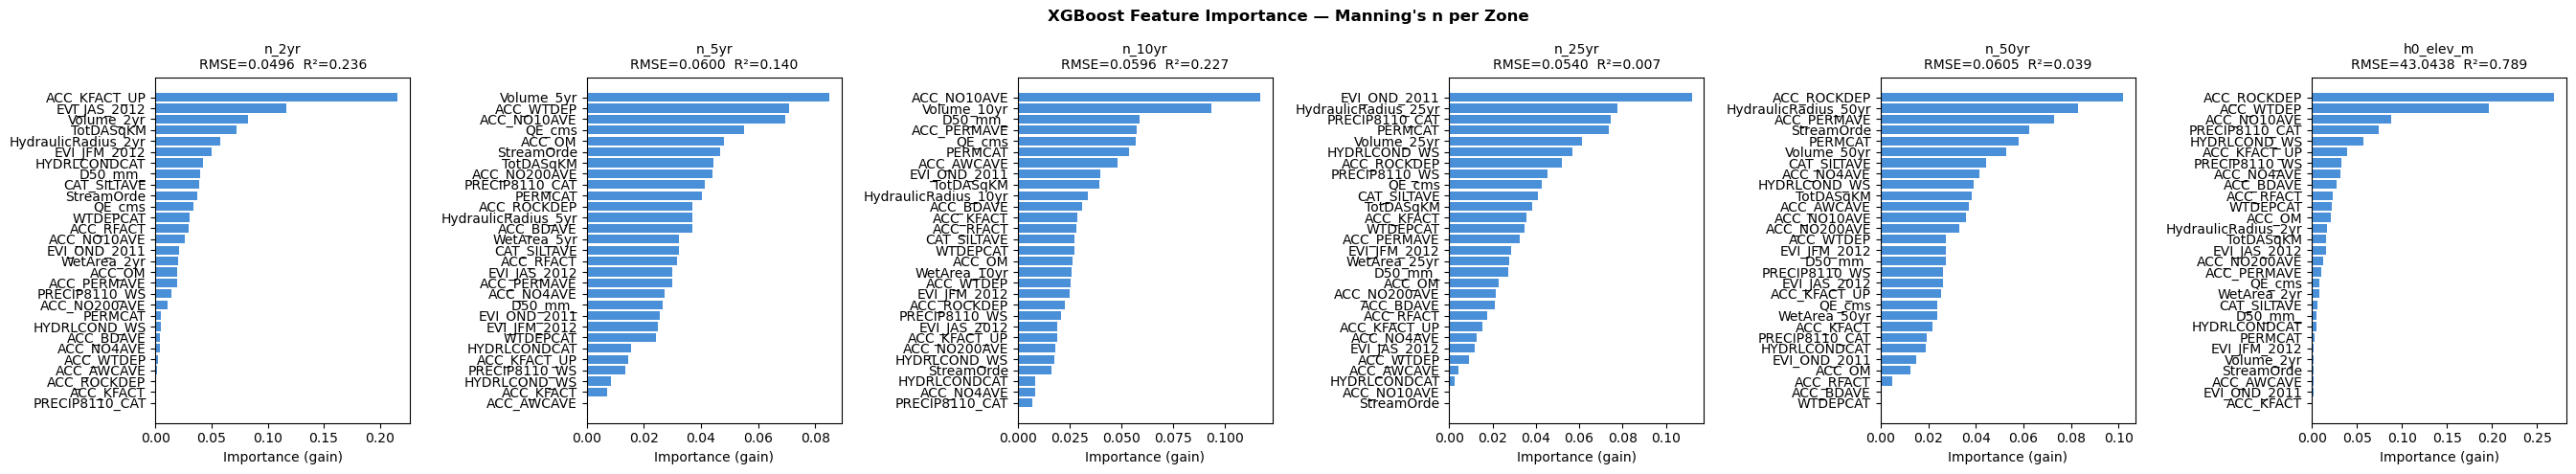

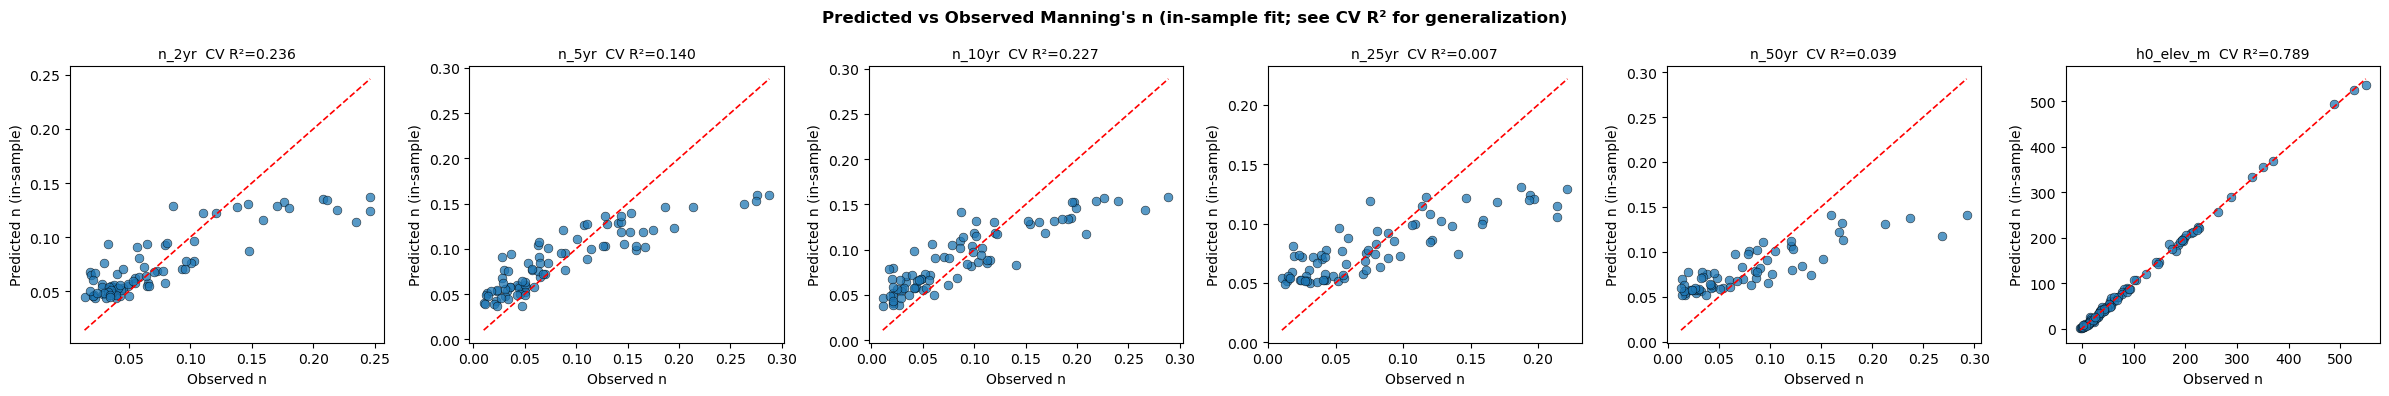

In [9]:
# ── XGBoost: one model per zone ────────────────────────────────────────────────────
#
# Each zone now uses its OWN feature set via feature_cols_for(zone): the base
# CONUS predictors (unchanged) plus that zone's HydraulicRadius/WetArea/Volume
# pulled from the gauge's own hydroTable at the zone's recurrence discharge
# (Step 0b) instead of the external file's mismatched static geometry.
#
# n per zone is only 54-68 gauges, so evaluation is k-fold CV throughout (not
# a single train/test split — see prior discussion on why that was unstable).
#
# NOTE: the CONUS-wide prediction step from earlier versions is dropped here —
# it needs zone-specific geometry for ~2.16M ungauged COMIDs, which only
# exists where we've already run HAND (i.e. for these gauges themselves).
# This cell is now a training/CV diagnostic only, not a deployable regionalizer.

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)
CV_FOLDS = 5

zone_data    = {}
zone_features = {}
for zone in TARGET_COLS:
    cols = feature_cols_for(zone)
    df_zone = df_ml[cols + [zone]].dropna()
    zone_data[zone]     = df_zone
    zone_features[zone] = cols
    print(f"{zone}: {len(df_zone)} training samples after dropping NaN  (features: {cols[-3:]})")

if max(len(d) for d in zone_data.values()) < 3:
    print("⚠  Too few samples — add more HUCs to HUC.txt and re-run.")
else:
    models  = {}
    metrics = {}
    Xs      = {}
    ys      = {}

    for zone in TARGET_COLS:
        df_zone   = zone_data[zone]
        cols      = zone_features[zone]
        X         = df_zone[cols].values
        y         = df_zone[zone].values
        n_samples = len(df_zone)
        Xs[zone]  = X
        ys[zone]  = y

        if n_samples < 3:
            print(f"⚠  {zone}: too few samples ({n_samples}) — skipping")
            continue

        xgb = XGBRegressor(**XGB_PARAMS)
        cv  = KFold(n_splits=min(n_samples, CV_FOLDS), shuffle=True, random_state=42)
        neg_mse = cross_val_score(xgb, X, y, cv=cv, scoring="neg_mean_squared_error")
        r2_cv   = cross_val_score(xgb, X, y, cv=cv, scoring="r2")
        rmse = float(np.sqrt(-neg_mse.mean()))
        r2   = float(r2_cv.mean())
        xgb.fit(X, y)   # refit on full data for feature importance
        metrics[zone] = {"RMSE": rmse, "R2": r2, "mode": f"{cv.get_n_splits()}-fold CV", "n": n_samples}

        models[zone] = xgb

    # ── Print metrics table ──────────────────────────────────────────────────────────
    print(f"\n{'Zone':<10}{'Mode':<14}{'n':>5}{'RMSE':>8}{'R²':>8}")
    print("-" * 47)
    for zone, m in metrics.items():
        print(f"{zone:<10}{m['mode']:<14}{m['n']:>5}{m['RMSE']:>8.4f}{m['R2']:>8.3f}")

    trained_zones = list(models.keys())

    # ── Feature importance per zone ──────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, len(trained_zones),
        figsize=(4.5 * len(trained_zones), 5),
        sharey=False,
    )
    if len(trained_zones) == 1:
        axes = [axes]
    for ax, zone in zip(axes, trained_zones):
        cols  = zone_features[zone]
        imp   = models[zone].feature_importances_
        order = np.argsort(imp)
        ax.barh([cols[i] for i in order], imp[order], color="#4a90d9")
        ax.set_title(f"{zone}\nRMSE={metrics[zone]['RMSE']:.4f}  R²={metrics[zone]['R2']:.3f}",
                     fontsize=10)
        ax.set_xlabel("Importance (gain)")
    fig.suptitle("XGBoost Feature Importance — Manning's n per Zone",
                 fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Predicted vs observed (full-data refit, in-sample) ───────────────────────────
    fig, axes = plt.subplots(
        1, len(trained_zones),
        figsize=(4 * len(trained_zones), 4),
    )
    if len(trained_zones) == 1:
        axes = [axes]
    for ax, zone in zip(axes, trained_zones):
        y     = ys[zone]
        y_hat = models[zone].predict(Xs[zone])
        ax.scatter(y, y_hat, alpha=0.75, s=40, edgecolors="k", linewidths=0.4)
        lo, hi = min(y.min(), y_hat.min()), max(y.max(), y_hat.max())
        ax.plot([lo, hi], [lo, hi], "r--", lw=1.2)
        ax.set_xlabel("Observed n")
        ax.set_ylabel("Predicted n (in-sample)")
        ax.set_title(f"{zone}  CV R²={metrics[zone]['R2']:.3f}", fontsize=10)
    fig.suptitle("Predicted vs Observed Manning's n (in-sample fit; see CV R² for generalization)",
                 fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()

In [10]:
# ── Simpler models: Ridge / Lasso / Random Forest ─────────────────────────────────
#
# Same per-zone feature set as the XGBoost cell above (feature_cols_for(zone),
# own-hydroTable geometry). 54-68 gauges per zone with ~19 features is thin
# for a flexible non-linear model; Ridge/Lasso are lower-variance at this N,
# and Lasso's surviving coefficients double as a feature-selection check.

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

ALPHAS = np.logspace(-3, 3, 25)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=3,
    max_features=0.6,
    random_state=42,
    n_jobs=-1,
)
OTHER_MODELS = {
    "Ridge": lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS)),
    "Lasso": lambda: make_pipeline(StandardScaler(), LassoCV(alphas=ALPHAS, max_iter=20000, random_state=42)),
    "RF":    lambda: RandomForestRegressor(**RF_PARAMS),
}

other_metrics = {}
other_fitted  = {}
for zone in TARGET_COLS:
    df_zone   = zone_data[zone]
    cols      = zone_features[zone]
    X         = df_zone[cols].values
    y         = df_zone[zone].values
    n_samples = len(df_zone)
    if n_samples < 3:
        continue
    cv = KFold(n_splits=min(n_samples, CV_FOLDS), shuffle=True, random_state=42)
    for name, make_model in OTHER_MODELS.items():
        model   = make_model()
        neg_mse = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
        r2_cv   = cross_val_score(model, X, y, cv=cv, scoring="r2")
        rmse    = float(np.sqrt(-neg_mse.mean()))
        r2      = float(r2_cv.mean())
        model.fit(X, y)   # refit on full data for coefficients / importances
        other_metrics[(zone, name)] = {"RMSE": rmse, "R2": r2, "n": n_samples}
        other_fitted[(zone, name)]  = model

# ── Comparison table: XGBoost vs Ridge vs Lasso vs RF ─────────────────────────────
print(f"{'Zone':<10}{'Model':<8}{'n':>5}{'RMSE':>8}{'R²':>8}")
print("-" * 39)
for zone in TARGET_COLS:
    if zone not in metrics:
        continue
    print(f"{zone:<10}{'XGB':<8}{metrics[zone]['n']:>5}{metrics[zone]['RMSE']:>8.4f}{metrics[zone]['R2']:>8.3f}")
    for name in OTHER_MODELS:
        m = other_metrics.get((zone, name))
        if m:
            print(f"{'':<10}{name:<8}{m['n']:>5}{m['RMSE']:>8.4f}{m['R2']:>8.3f}")
    print()

# ── Lasso coefficients (which predictors survive shrinkage) ──────────────────────
print("Lasso non-zero coefficients (standardized) by zone:")
for zone in TARGET_COLS:
    pipe = other_fitted.get((zone, "Lasso"))
    if pipe is None:
        continue
    lasso = pipe.named_steps["lassocv"]
    cols  = zone_features[zone]
    nz = [(f, round(float(c), 4)) for f, c in zip(cols, lasso.coef_) if abs(c) > 1e-6]
    print(f"  {zone}: alpha={lasso.alpha_:.4g}  {nz if nz else '(all coefficients shrunk to 0)'}")

# ── RF feature importances ────────────────────────────────────────────────────────
print("\nRandom Forest feature importances by zone:")
for zone in TARGET_COLS:
    rf = other_fitted.get((zone, "RF"))
    if rf is None:
        continue
    cols  = zone_features[zone]
    order = np.argsort(rf.feature_importances_)[::-1]
    top = [(cols[i], round(float(rf.feature_importances_[i]), 3)) for i in order[:4]]
    print(f"  {zone}: top features {top}")

Zone      Model       n    RMSE      R²
---------------------------------------
n_2yr     XGB        83  0.0496   0.236
          Ridge      83  0.0444   0.305
          Lasso      83  0.0468   0.232
          RF         83  0.0500   0.164

n_5yr     XGB        82  0.0600   0.140
          Ridge      82  0.0597   0.115
          Lasso      82  0.0653  -0.173
          RF         82  0.0583   0.193

n_10yr    XGB        82  0.0596   0.227
          Ridge      82  0.0582   0.255
          Lasso      82  0.0627   0.107
          RF         82  0.0588   0.239

n_25yr    XGB        73  0.0540   0.007
          Ridge      73  0.0460   0.223
          Lasso      73  0.0497   0.096
          RF         73  0.0499   0.130

n_50yr    XGB        64  0.0605   0.039
          Ridge      64  0.0567   0.166
          Lasso      64  0.0541   0.252
          RF         64  0.0577   0.145

h0_elev_m XGB        96 43.0438   0.789
          Ridge      96 57.9015   0.661
          Lasso      96 52.1395   0

In [11]:
# CONUS-wide prediction is not produced in this version: the corrected
# HydraulicRadius/WetArea/Volume features only exist where we already have a
# hydroTable (i.e. for the calibrated gauges), not for the ~2.16M ungauged
# CONUS reaches in the predictor file. Deploying a regionalizer would need
# either (a) accepting the external file's mismatched geometry again for
# CONUS-scale prediction, or (b) computing HAND geometry ourselves at CONUS
# scale — both bigger decisions than this notebook should make silently.

### Geometry source comparison: own hydroTable (zone-specific) vs external CONUS file (static)

Same 125-gauge dataset, same models, same CV setup -- only the
HydraulicRadius/WetArea/Volume features differ: zone-specific values from
each gauge's own hydroTable (what we've been using) vs the external CONUS
predictor file's static values (verified earlier not to match this
pipeline's geometry for the same reach, but the only version available for
ungauged reaches). This isolates how much of the improvement came from more
gauges vs. from fixing the geometry mismatch, and shows what a genuinely
CONUS-deployable model's performance ceiling looks like with today's data.

In [12]:
from sklearn.model_selection import KFold, cross_val_score

ext_metrics = {}
for zone in TARGET_COLS:
    df_zone = df_ml[EXT_FEATURE_COLS + [zone]].dropna()
    X = df_zone[EXT_FEATURE_COLS].values
    y = df_zone[zone].values
    n_samples = len(df_zone)
    if n_samples < 3:
        continue
    cv = KFold(n_splits=min(n_samples, CV_FOLDS), shuffle=True, random_state=42)

    row = {"n": n_samples}
    xgb = XGBRegressor(**XGB_PARAMS)
    row["XGB"] = float(cross_val_score(xgb, X, y, cv=cv, scoring="r2").mean())
    for name, make_model in OTHER_MODELS.items():
        model = make_model()
        row[name] = float(cross_val_score(model, X, y, cv=cv, scoring="r2").mean())
    ext_metrics[zone] = row

print(f"{'Zone':<10}{'Model':<8}{'n':>5}{'OwnGeom R²':>12}{'ExtGeom R²':>12}")
print("-" * 47)
for zone in TARGET_COLS:
    if zone not in ext_metrics:
        continue
    own_n = metrics[zone]["n"]
    ext_n = ext_metrics[zone]["n"]
    print(f"{zone:<10}{'XGB':<8}{f'{own_n}/{ext_n}':>5}{metrics[zone]['R2']:>12.3f}{ext_metrics[zone]['XGB']:>12.3f}")
    for name in OTHER_MODELS:
        own_r2 = other_metrics.get((zone, name), {}).get("R2")
        ext_r2 = ext_metrics[zone].get(name)
        own_s = f"{own_r2:.3f}" if own_r2 is not None else "  n/a"
        ext_s = f"{ext_r2:.3f}" if ext_r2 is not None else "  n/a"
        print(f"{'':<10}{name:<8}{'':>5}{own_s:>12}{ext_s:>12}")
    print()

Zone      Model       n  OwnGeom R²  ExtGeom R²
-----------------------------------------------
n_2yr     XGB     83/83       0.236      -0.274
          Ridge               0.305      -0.262
          Lasso               0.232      -0.172
          RF                  0.164      -0.601

n_5yr     XGB     82/82       0.140      -0.027
          Ridge               0.115      -0.049
          Lasso              -0.173       0.018
          RF                  0.193      -0.074

n_10yr    XGB     82/82       0.227       0.069
          Ridge               0.255      -0.074
          Lasso               0.107      -0.054
          RF                  0.239      -0.035

n_25yr    XGB     73/73       0.007      -0.045
          Ridge               0.223      -0.195
          Lasso               0.096      -0.165
          RF                  0.130       0.005

n_50yr    XGB     64/64       0.039      -0.092
          Ridge               0.166      -0.553
          Lasso               0.252 